# Рахимьянов Альберт, ЕТ-128, "Поиск частых наборов"

1. Выполните поиск частых наборов объектов в наборе данных с помощью следующих алгоритмов (или их модификаций): Apriori, FP‑Growth, ECLAT. Варьируйте пороговое значение поддержки (например: 1%, 3%, 5%, 10%, 15%, 20%). Проверьте идентичность результатов, полученных с помощью различных алгоритмов.
2. Подготовьте список частых наборов, в которых не более семи объектов (разумное количество). Проанализируйте и изложите содержательный смысл полученного результата.
3. Выполните визуализацию полученных результатов в виде следующих диаграмм:
сравнение быстродействия алгоритмов на фиксированном наборе данных при изменяемом пороге поддержки;
общее количество частых наборов объектов на фиксированном наборе данных при изменяемом пороге поддержки;
максимальная длина частого набора объектов на фиксированном наборе данных при изменяемом пороге поддержки;
количество частых наборов объектов различной длины на фиксированном наборе данных при изменяемом пороге поддержки.
4. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. - сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.

In [5]:
import warnings
warnings.filterwarnings("ignore")
# sns.set(style="whitegrid")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
# Библиотеки
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth
from itertools import combinations
import time
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Загрузка датасета
from google.colab import drive
drive.mount('/content/drive')

baskets = '/content/drive/MyDrive/Colab Notebooks/Semestr2/IAD/baskets.csv'

df = pd.read_csv(baskets, sep=',', header=None, encoding='cp1251')
df.head()

Mounted at /content/drive


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,креветки,миндаль,авокадо,овощная смесь,зеленый виноград,цельнозерновая мука,батат,творог,энергетический напиток,томатный сок,низкокалорийный йогурт,зеленый чай,мед,салат,минеральная вода,лосось,ягодный сок,замороженный смузи,шпинат,оливковое масло
1,гамбургер,фрикадельки,яйца,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,чатни,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,индейка,авокадо,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,минеральная вода,молоко,энергетический батончик,рис,зеленый чай,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# one-hot преобразование транзакций
transactions = df.apply(lambda row: row.dropna().tolist(), axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_onehot = pd.DataFrame(te_array, columns=te.columns_)
# df_onehot = df_onehot.fillna(0)
df_onehot.head()

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [9]:
# Реализация алгоритма ECLAT
def eclat(df, min_support=0.05):
    n_transactions = len(df)

    # Преобразуем в вертикальный формат
    item_tidset = {}
    for col in df.columns:
        item_tidset[frozenset([col])] = set(df.index[df[col] == 1])

    frequent_itemsets = {}

    def recursive_eclat(itemsets, min_support):
        new_itemsets = {}
        itemsets_list = list(itemsets.items())

        for i in range(len(itemsets_list)):
            item_i, tid_i = itemsets_list[i]
            support_i = len(tid_i) / n_transactions

            if support_i >= min_support:
                frequent_itemsets[item_i] = support_i

                for j in range(i+1, len(itemsets_list)):
                    item_j, tid_j = itemsets_list[j]
                    new_item = item_i.union(item_j)
                    new_tid = tid_i.intersection(tid_j)

                    if len(new_tid) / n_transactions >= min_support:
                        new_itemsets[new_item] = new_tid

        if new_itemsets:
            recursive_eclat(new_itemsets, min_support)

    recursive_eclat(item_tidset, min_support)

    return pd.DataFrame({
        'itemsets': list(frequent_itemsets.keys()),
        'support': list(frequent_itemsets.values())
    })

In [10]:
supports = [0.01, 0.03, 0.05, 0.10, 0.15, 0.20] # Минимальные поддержки
summary_results = []

for s in supports:
    print(f"\n  Минимальная поддержка = {s}")
    print("|-----------------------------------------------------------------------------------------------------------------------------|")

    algorithms = {
        "Apriori": apriori,
        "FP-Growth": fpgrowth,
        "ECLAT": eclat
    }

    for name, algo in algorithms.items():
        start_time = time.perf_counter()  # Начало замера
        result = algo(df_onehot, min_support=s, use_colnames=True) \
                 if name != "ECLAT" else algo(df_onehot, min_support=s)
        end_time = time.perf_counter()    # Конец замера

        execution_time = end_time - start_time

        # Общее количество наборов
        total_itemsets = len(result)

        # Длина наборов
        if total_itemsets > 0:
            result["length"] = result["itemsets"].apply(len)
            max_length = result["length"].max()
            length_distribution = result["length"].value_counts().sort_index()
        else:
            max_length = 0
            length_distribution = {}

        # Вывод
        print(f"\nАлгоритм: {name}, время: {execution_time:.2f} сек, общее кол-во: {total_itemsets}, максимально: {max_length}, Кол-во наборов по длинам:")

        if total_itemsets > 0:
            for length, count in length_distribution.items():
                print(f"  Длина {length}: {count}")
        else:
            print("  Нет частых наборов")

        # Сохраняем для возможного анализа
        summary_results.append({
            "support": s,
            "algorithm": name,
            "time_sec": execution_time,
            "total_itemsets": total_itemsets,
            "max_length": max_length,
            "length_distribution": dict(length_distribution)
        })


  Минимальная поддержка = 0.01
|-----------------------------------------------------------------------------------------------------------------------------|

Алгоритм: Apriori, время: 0.18 сек, общее кол-во: 261, максимально: 3, Кол-во наборов по длинам:
  Длина 1: 74
  Длина 2: 170
  Длина 3: 17

Алгоритм: FP-Growth, время: 5.62 сек, общее кол-во: 261, максимально: 3, Кол-во наборов по длинам:
  Длина 1: 74
  Длина 2: 170
  Длина 3: 17

Алгоритм: ECLAT, время: 0.13 сек, общее кол-во: 261, максимально: 3, Кол-во наборов по длинам:
  Длина 1: 74
  Длина 2: 170
  Длина 3: 17

  Минимальная поддержка = 0.03
|-----------------------------------------------------------------------------------------------------------------------------|

Алгоритм: Apriori, время: 0.03 сек, общее кол-во: 55, максимально: 2, Кол-во наборов по длинам:
  Длина 1: 36
  Длина 2: 19

Алгоритм: FP-Growth, время: 0.52 сек, общее кол-во: 55, максимально: 2, Кол-во наборов по длинам:
  Длина 1: 36
  Длина 2: 19

Алго

In [11]:
min_support = 0.01 # Минимальная поддержка

frequent_itemsets = apriori(df_onehot, min_support=min_support, use_colnames=True)

# Длина набора
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)

# Оставляем наборы длиной <= 7 (но таких в целом нет в наборе)
# frequent_itemsets = frequent_itemsets[frequent_itemsets["length"] <= 7]

frequent_itemsets

,support,itemsets,length
0,0.033329,(авокадо),1
1,0.013198,(баклажаны),1
2,0.011465,(батат),1
3,0.016531,(белое вино),1
4,0.013598,(белый сыр),1
...,...,...,...
256,0.011199,"(молоко, шоколад, макароны)",3
257,0.010932,"(шоколад, яйца, макароны)",3
258,0.013998,"(минеральная вода, молоко, шоколад)",3
259,0.013065,"(минеральная вода, молоко, яйца)",3


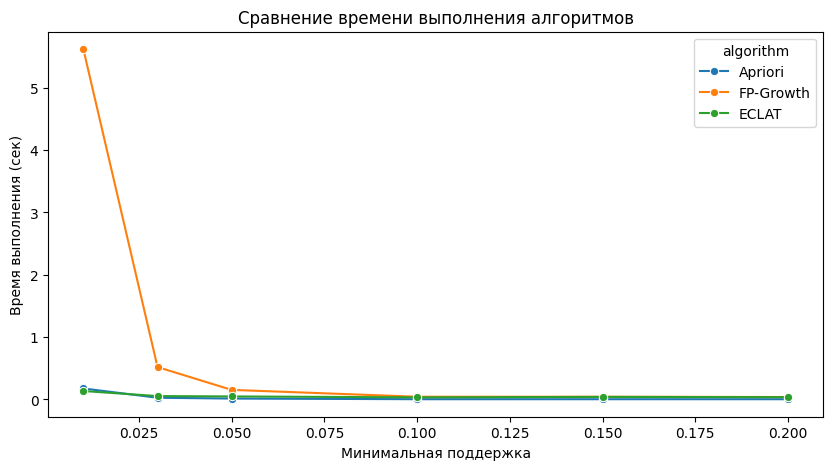

In [12]:
# Быстродействие алгоритмов с изменяемым уровнем минимальной поддержки
df_summary = pd.DataFrame(summary_results)

plt.figure(figsize=(10,5))
sns.lineplot(data=df_summary, x="support", y="time_sec", hue="algorithm", marker="o")
plt.title("Сравнение времени выполнения алгоритмов")
plt.xlabel("Минимальная поддержка")
plt.ylabel("Время выполнения (сек)")
plt.show()

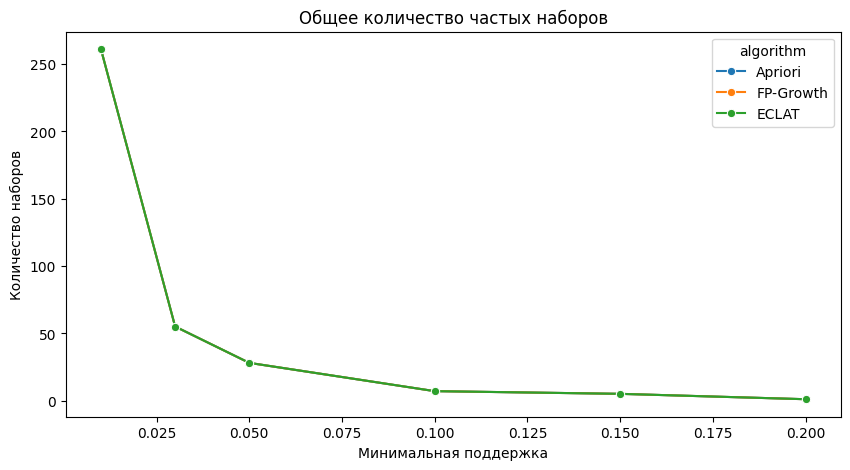

In [13]:
# Общее колиество найденных частых наборов в зависимости от урованя минимальной поддержки

plt.figure(figsize=(10,5))
sns.lineplot(data=df_summary, x="support", y="total_itemsets", hue="algorithm", marker="o")
plt.title("Общее количество частых наборов")
plt.xlabel("Минимальная поддержка")
plt.ylabel("Количество наборов")
plt.show()

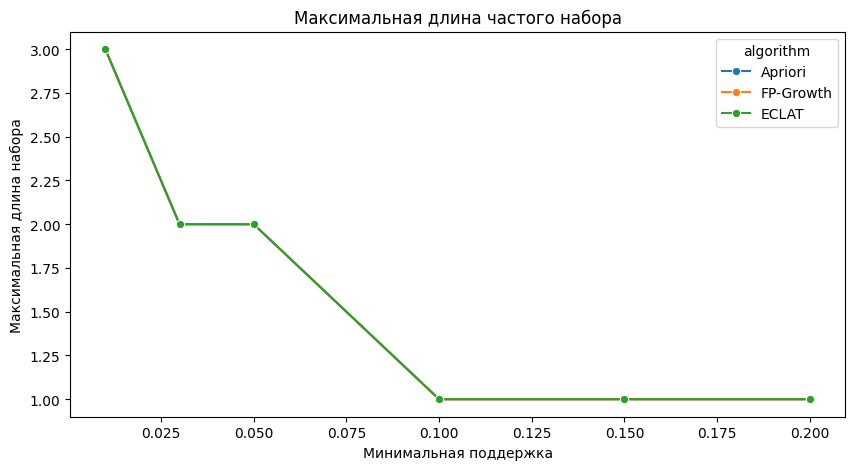

In [14]:
# Максимальная длина частого набора для уровня поддержки

plt.figure(figsize=(10,5))
sns.lineplot(data=df_summary, x="support", y="max_length", hue="algorithm", marker="o")
plt.title("Максимальная длина частого набора")
plt.xlabel("Минимальная поддержка")
plt.ylabel("Максимальная длина набора")
plt.show()

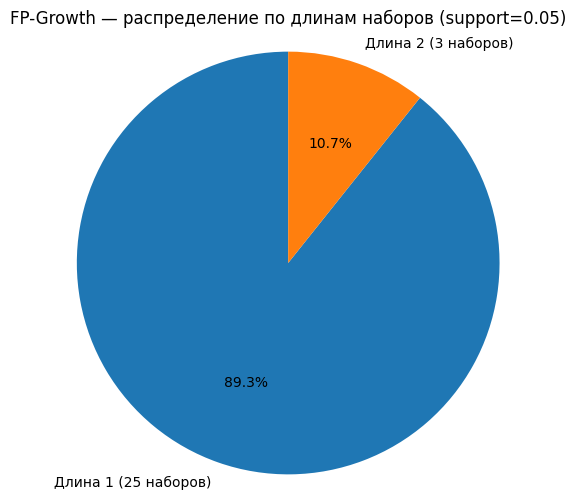

In [20]:
# Распределение общего числа наборов по длинам конкетного алгоритма и уровнем поддержки

chosen_support = 0.05           # После 0.03 длина < 3
chosen_algorithm = "FP-Growth"  # Apriori FP-Growth ECLAT

row = df_summary[(df_summary["support"] == chosen_support) &
                 (df_summary["algorithm"] == chosen_algorithm)].iloc[0]

length_dist = row["length_distribution"]

labels = [f"Длина {k} ({v} наборов)" for k, v in length_dist.items()]
sizes = length_dist.values()

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(f"{chosen_algorithm} — распределение по длинам наборов (support={chosen_support})")
plt.axis('equal')
plt.show()